## Training multiple linear regression model on haikyu's dataset

In [6]:
import pandas as pd
data=pd.read_csv("haikyu_players.csv")
data.head()

,Player,Attack,Defense,Speed,Jump,Overall
0,Hinata,95,70,98,100,91
1,Kageyama,88,82,85,88,87
2,Tsukishima,72,95,68,82,82
3,Nishinoya,70,98,96,85,88
4,Tanaka,92,72,80,86,84


In [7]:
X=data[["Attack","Defense","Speed","Jump"]]
y=data[["Overall"]]
X.head()
y.head()

,Overall
0,91
1,87
2,82
3,88
4,84


In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [10]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[0.33,0.22,0.17,0.02]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Attack','Defense','Speed','Jump']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[25.9]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [11]:
y_pred=model.predict(X_test)

In [12]:
print("Actual:",y_test.values)
print("Predicted:",y_pred)

Actual: [[95]
 [89]
 [91]]
Predicted: [[91.65016525]
 [89.5812795 ]
 [90.63599661]]


In [13]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 3.8972590523835016


In [14]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R sq:",r2)

R sq: 0.37365479515265143


In [15]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[0.32578957 0.21555797 0.16744001 0.02282966]]
Intercept: [25.90484166]


## Predict a new player

In [16]:
naruto = pd.DataFrame({
    "Attack": [100],
    "Defense": [100],
    "Speed": [100],
    "Jump": [100]
})

prediction = model.predict(naruto)

print("Predicted Overall:", prediction[0])

Predicted Overall: [99.06656352]


## Plotting graph

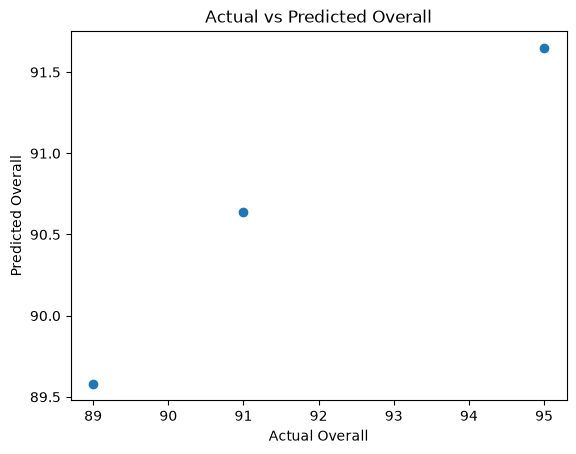

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Overall")
plt.ylabel("Predicted Overall")
plt.title("Actual vs Predicted Overall")

plt.show()

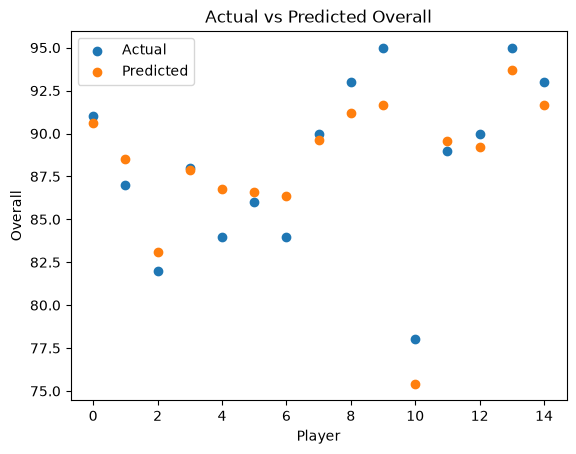

In [18]:
y_all_pred = model.predict(X)

plt.scatter(range(len(y)), y, label="Actual")
plt.scatter(range(len(y)), y_all_pred, label="Predicted")

plt.xlabel("Player")
plt.ylabel("Overall")
plt.title("Actual vs Predicted Overall")
plt.legend()
plt.show()